In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math as m

# Homeword Set 11

## 7.4

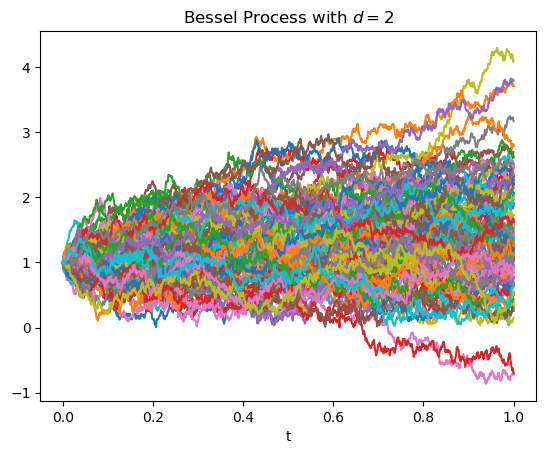

Paths that become negative for d=2: 2


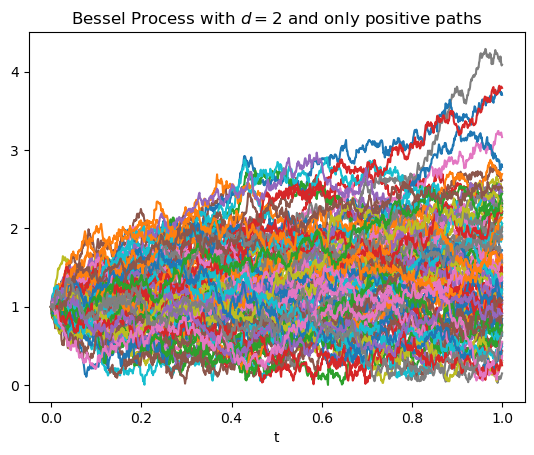

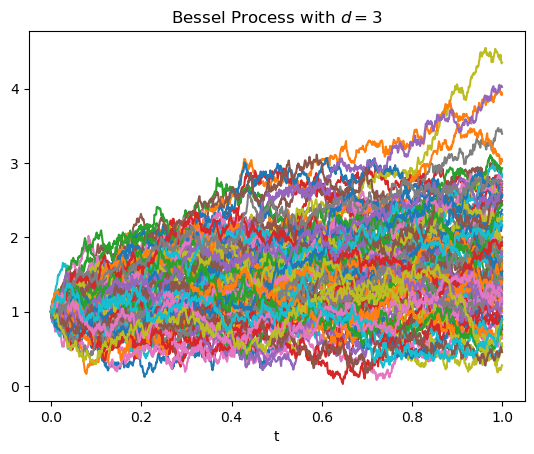

Paths that become negative for d=3: 0


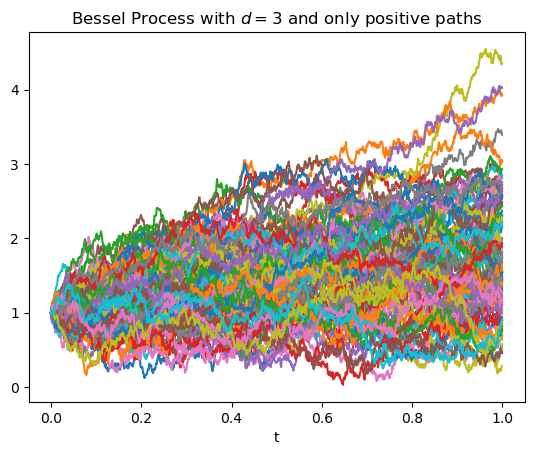

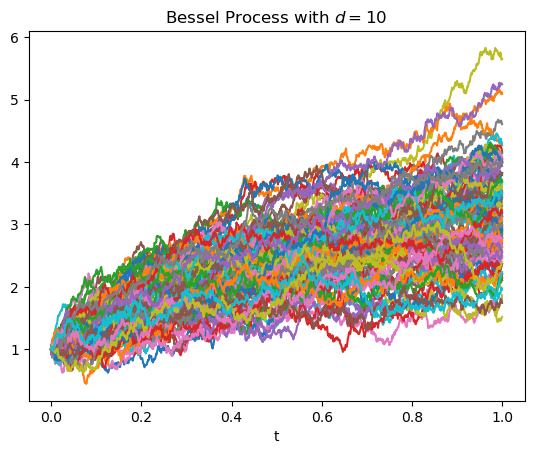

Paths that become negative for d=10: 0


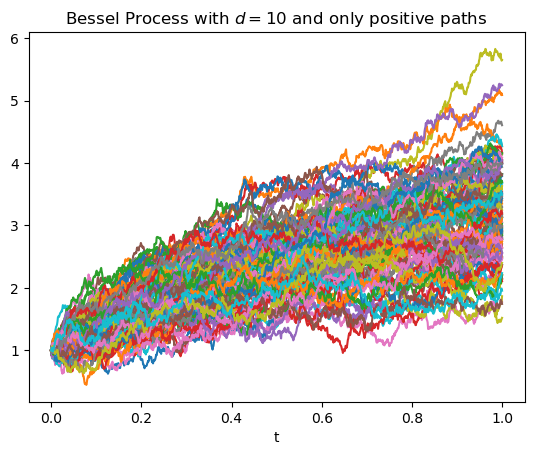

In [8]:
diff = 0.001
paths = 100
x = np.arange(0,1 + diff, diff)
Increments = np.random.normal(loc = 0, scale= m.sqrt(diff), size=(paths, len(x)-1))

for d in [2,3,10]:
    Rt = np.zeros(shape=(paths,len(x)))
    Rt[:,0] = 1
    for i in range(len(x)-1):
        Rt[:, i + 1] = Rt[:, i] + (Increments[:,i]) + (((d-1)/(2 * Rt[:,i]))* diff)
    
    plt.plot(x, Rt.T)
    plt.title(rf"Bessel Process with $d= {d}$")
    plt.xlabel("t")
    plt.show()

    stays_postive = np.argmax(Rt < 0, axis=1) == 0
    print(f"Paths that become negative for d={d}:", len(Rt) - np.count_nonzero(stays_postive))

    plt.plot(x, Rt[stays_postive].T)
    plt.title(rf"Bessel Process with $d= {d}$ and only positive paths")
    plt.xlabel('t')
    plt.show()

## 7.6

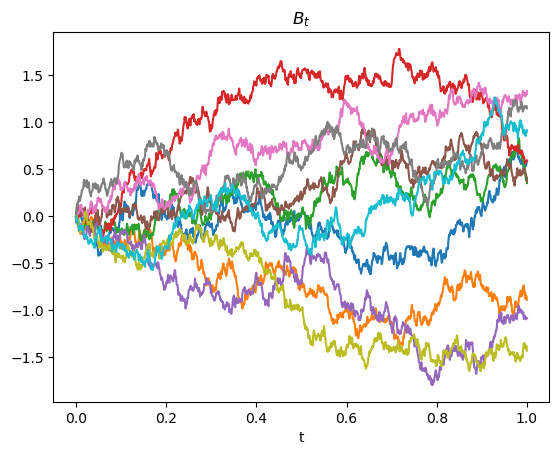

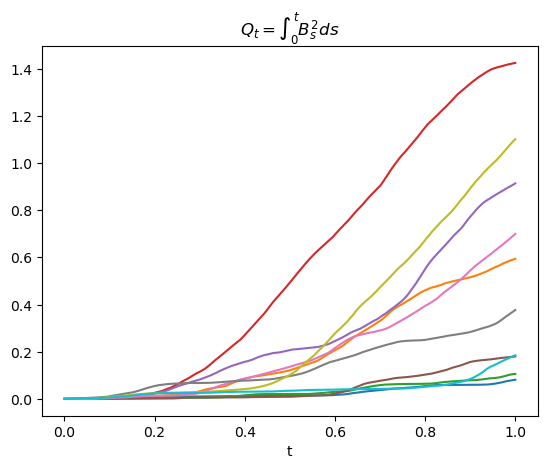

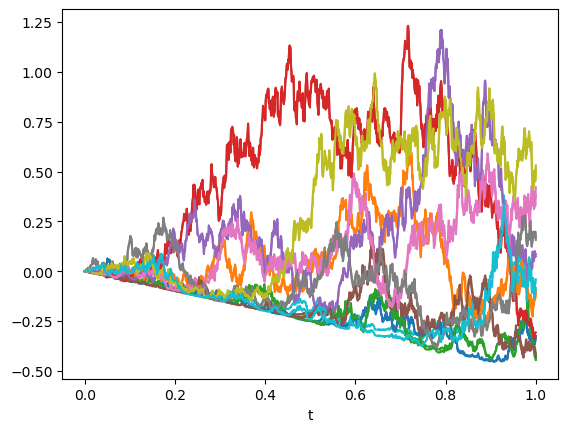

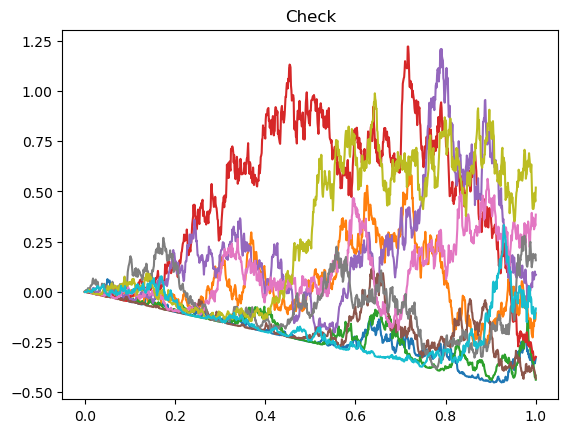

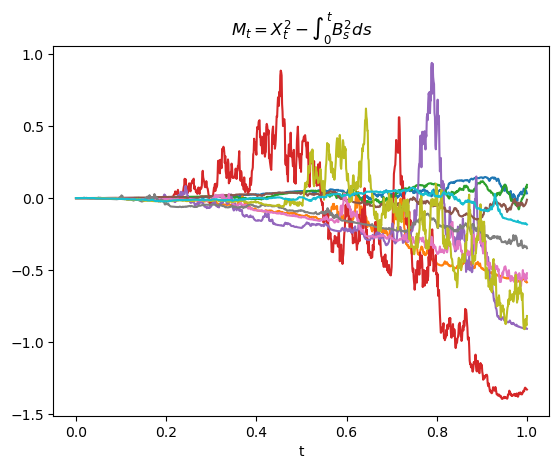

In [9]:
diff = 0.001
x = np.arange(0, 1 + diff, diff)
paths = 10
Increments = np.random.normal(loc = 0, scale= m.sqrt(diff), size=(paths, len(x)-1))


Samples = np.append(np.zeros(shape=(paths,1)), Increments, axis=1)
BM = np.cumsum(Samples, axis=1)

Xt = np.cumsum(np.insert(BM[:,:-1] * Increments, 0 , 0, axis=1), axis=1)

Q = np.cumsum(BM**2 * diff, axis=1)

Mt = Xt ** 2 - Q


plt.plot(x,BM.T)
plt.title(r"$B_t$")
plt.xlabel('t')
plt.show()

plt.plot(x,Q.T)
plt.title(r"$Q_t = \int_{0}^{t} B_{s}^2 ds$")
plt.xlabel('t')
plt.show()

plt.plot(x, Xt.T)
plt.plot(x, (.5 *(BM**2) - (.5 * x)).T)
plt.xlabel('t')
plt.show()

plt.plot(x, (.5 *(BM**2) - (.5 * x)).T)
plt.title("Check")
plt.show()

plt.plot(x,Mt.T)
plt.title(r"$M_t = X_t^2 - \int_{0}^{t} B_{s}^2 ds $")
plt.xlabel('t')
plt.show()
